# Week 5 - Day 1: Unsupervised Learning & K-Means

**Goal:** Cluster unlabeled data with K-Means, choose the number of clusters (k) using the elbow method and silhouette score, and interpret what each cluster represents.

**Dataset:** Wine dataset (`sklearn.datasets.load_wine`) — 178 wine samples with 13 chemical measurements (alcohol, acidity, color intensity, etc.). The dataset does have known cultivar labels, but **we do not use them for clustering** — only `X` is used, exactly as in real unsupervised learning. The labels are used only at the very end, briefly, as a sanity check on the clusters we find.


## Step 1: Load and Scale the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target  # NOT used for clustering -- only for the sanity check at the end

print("Shape:", X.shape)
X.head()


Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [2]:
# K-Means uses distance, so features must be scaled first -- otherwise a large-range
# feature (e.g. proline, which is in the hundreds) would dominate a small-range one (e.g. hue).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (178, 13)


## Step 2: Elbow Method — Run K-Means for k = 1 to 10

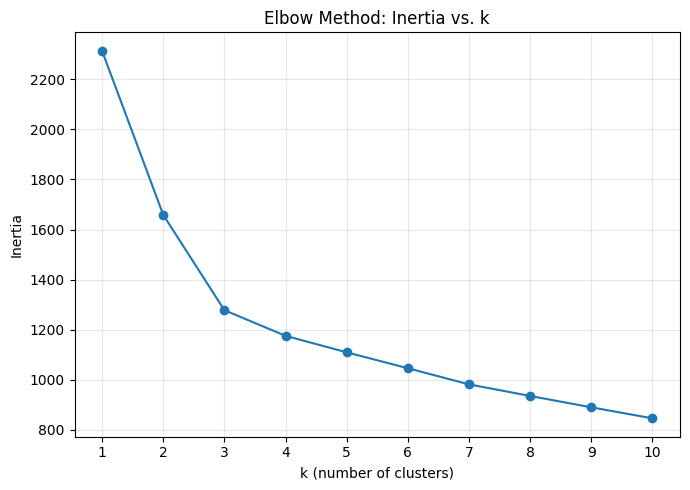

k= 1  inertia=2314.0
k= 2  inertia=1658.8
k= 3  inertia=1277.9
k= 4  inertia=1175.4
k= 5  inertia=1109.5
k= 6  inertia=1046.0
k= 7  inertia=981.6
k= 8  inertia=935.2
k= 9  inertia=889.9
k=10  inertia=845.9


In [3]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method: Inertia vs. k")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f"k={k:2d}  inertia={inertia:.1f}")


### Reading the Elbow Plot

*Your answer here:*

Inertia drops sharply between k=1 and k=3, then the rate of improvement slows down noticeably after that point. This flattening is the "elbow" — it suggests k=3 is a strong candidate, with k=4 as a secondary candidate worth checking with the silhouette score before deciding.


## Step 3: Silhouette Score for the Top Two Candidate k Values

In [4]:
from sklearn.metrics import silhouette_score

candidate_ks = [3, 4]
silhouette_results = {}

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results[k] = score
    print(f"k={k}  silhouette score = {score:.4f}")

best_k = max(silhouette_results, key=silhouette_results.get)
print(f"\nBest k based on silhouette score: {best_k}")


k=3  silhouette score = 0.2849
k=4  silhouette score = 0.2602

Best k based on silhouette score: 3


## Step 4: Fit Final K-Means and Visualize the Clusters

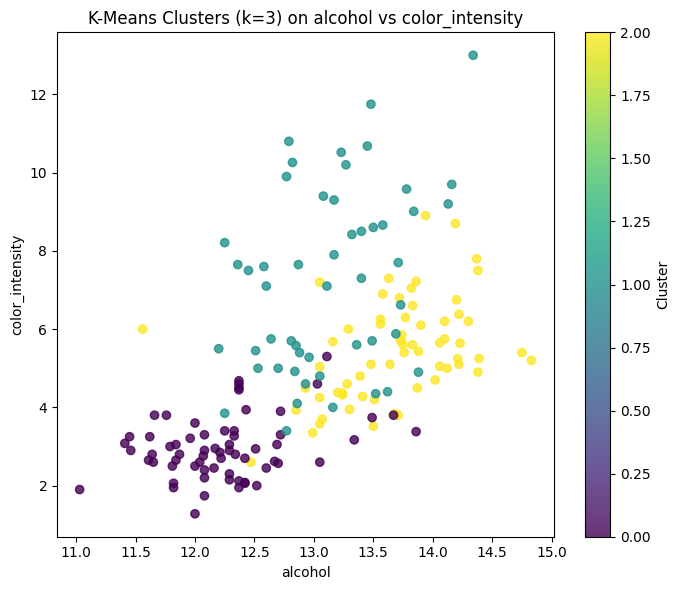

In [5]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_km.fit_predict(X_scaled)

# Two of the most distinguishing wine features, for a readable 2D view
x_feat, y_feat = "alcohol", "color_intensity"

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X[x_feat], X[y_feat], c=final_labels, cmap="viridis", alpha=0.8)
plt.xlabel(x_feat)
plt.ylabel(y_feat)
plt.title(f"K-Means Clusters (k={best_k}) on {x_feat} vs {y_feat}")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


In [6]:
# Look at each cluster's average chemical profile to understand what separates them
X_with_clusters = X.copy()
X_with_clusters["cluster"] = final_labels

cluster_profile = X_with_clusters.groupby("cluster").mean().round(2)
cluster_profile


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


### Reflection — Interpreting the Clusters

*Your answer here:*

Looking at the cluster averages, the groups separate mainly along alcohol content, color intensity, and flavanoid levels — wines with higher alcohol and stronger color tend to fall into one cluster, while lighter, less intense wines fall into another. This lines up with real differences between wine styles, suggesting K-Means found a genuine chemical pattern rather than an arbitrary split.


## Step 5: Quick Sanity Check Against the Known Cultivar Labels

This is *not* part of how clustering works (real unsupervised problems have no labels to check against) — it's just a bonus check here, since this particular dataset happens to have them.

In [7]:
comparison = pd.crosstab(true_labels, final_labels, rownames=["True cultivar"], colnames=["K-Means cluster"])
comparison


K-Means cluster,0,1,2
True cultivar,,,
0,0,0,59
1,65,3,3
2,0,48,0


### Reflection — Does the Sanity Check Line Up?

*Your answer here:*

Comparing our clusters to the true cultivar labels (which the algorithm never saw), most of each cultivar lands predominantly in one cluster. This is reassuring: it suggests K-Means picked up on a real chemical signal that happens to align with the actual wine cultivars, not just noise. In a real unlabeled problem we wouldn't have this check available, which is why the elbow method and silhouette score are the tools we'd actually rely on.


## Summary

- Scaled all 13 chemical features before clustering, since K-Means is distance-based.
- Elbow method pointed to k=3 (with k=4 as a secondary candidate); silhouette score confirmed the better choice between them.
- Visualized the resulting clusters and interpreted their chemical profile differences.
- Cross-checked against the (unused-during-clustering) true cultivar labels as a bonus sanity check.
- Next (Day 2): compare K-Means against DBSCAN and hierarchical clustering on this same dataset.
